# Development data - analysis

## Prepare workspace

In [ ]:
# Load libraries
library("readxl")
library("tidyverse")
library("ggbreak") 
library("RColorBrewer")
library("scales")
library("svglite")
library("ggtext")

# Set working directory
wd <- "/path/to"
setwd(wd)

# Set path to Excel data
excel_data_path <- file.path(wd, "02_data", "tables", "development_data.xlsx")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
ggbreak v0.1.4 Learn more at https://yulab-smu.top/



If you use ggbreak in published research, please cite the following
paper:

S Xu, M Chen, T Feng, L Zhan, L Zhou, G Yu. Use ggbreak to effectively
utilize plotting space to deal with large datasets and outliers.
Frontiers in Genetics. 2021, 12:774846. doi: 10.3389/fgene.2021.774846



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘

### Set colors and paremeters

In [40]:
strain_levels <- c("wt", "ko", "re")
wt_colors <- brewer.pal(n = 9, name = "Greens")
disfp_colors <- brewer.pal(n = 9, name = "Purples")
rescue_colors <- brewer.pal(n = 9, name = "Blues")
color_nr <- 6

strain_colors <- c("wt" = wt_colors[color_nr],
                   "ko" = disfp_colors[color_nr],
                   "re" = rescue_colors[color_nr])

strain_rename <- c(
  "ko" = expression(italic(disfp)^"–" * " \n mutant"),
  "re" = expression(italic(disfp)^"–" * " \n rescue"), 
  "wt" = expression("Ax2 wild-type")
)

## Spore production

Load data

In [5]:
# Load and 
data_spores_raw <- read_excel(excel_data_path, sheet = "SporeProduction")

# Reshape the dataframe
data_spores <- data_spores_raw %>%
  pivot_longer(cols = everything(), names_to = "strain", values_to = "spore_count") %>%
  mutate(
    spore_count = spore_count * 10^5,
    strain = case_when(
      strain == 'AX2' ~ 'wt',
      strain == 'Disfp_ko' ~ 'ko',
      strain == 'Disfp_ko_R' ~ 're'
    ),
    strain = factor(strain, levels = strain_levels)
  )

Perform ANOVA

In [8]:
# Perform ANOVA on log10-transformed spore counts
anova_model <- aov(log10(spore_count) ~ strain, data = data_spores)

# Tukey post-hoc test
tukey_test <- TukeyHSD(anova_model)

# Convert the matrix to a data frame with comparison names
tukey_results <- tukey_test$`strain`
tukey_results <- data.frame(Comparison = rownames(tukey_results), tukey_results)

# Add significance labels
tukey_results <- tukey_results %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))

# Set y-position for significance annotations
y_sigline <- 0.8 * 10^6

annotations <- data.frame(
  x_min = c(1.1, 2.1, 1.1),
  x_max = c(1.9, 2.9, 2.9),
  y     = c(y_sigline, y_sigline, y_sigline * 2.1),
  label = tukey_results$significance
)

Plot

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encodin

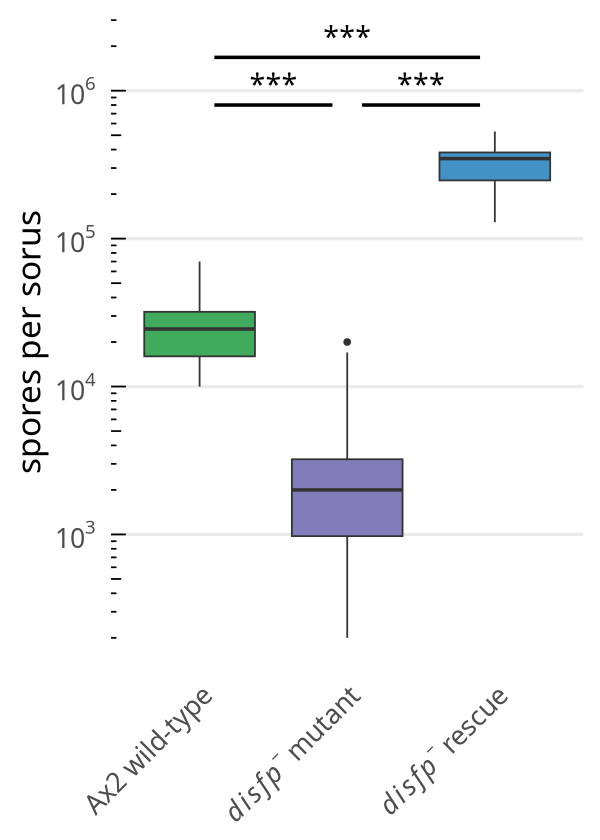

In [41]:
options(repr.plot.width = 5, repr.plot.height = 7)

# Generate boxplot for spore production
p_sporeP <- data_spores %>%
  ggplot(aes(x = strain, y = (spore_count / 10), fill = strain)) +
  geom_boxplot(alpha = 1) +
  geom_segment(data = annotations, aes(x = x_min, xend = x_max, y = y, yend = y),
               inherit.aes = FALSE, color = "black", size = 1) +
  geom_text(data = annotations, aes(x = (x_min + x_max) / 2, y = y, label = label),
            inherit.aes = FALSE, vjust = -0.5, size = 6) +
  scale_fill_manual(values = strain_colors) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "spores per sorus") +
  theme_minimal(base_size = 20) +
  scale_y_log10(
    breaks = trans_breaks("log10", function(x) 10^x),
    labels = trans_format("log10", math_format(10^.x)),
    limits = c(NA, 0.2 * 10^7)
  ) +
  guides(fill = FALSE) +
  annotation_logticks(sides = "l") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    strip.text.x = element_text(color = "black", face = "bold"),
    strip.background = element_rect(colour = "white", fill = "white", size = NA, linetype = "solid")
  )

# Display plot
p_sporeP


## Spore viability

### Prepare data

In [19]:
# Load data
data_sporeV_raw <- read_excel(excel_data_path, sheet = "Spore_viability")

# Reshape and rename strains
data_sporeV <- data_sporeV_raw %>%
  pivot_longer(cols = everything(), names_to = "strain", values_to = "spore_viability") %>%
  mutate(
    strain = case_when(
      strain == "AX2" ~ "wt",
      strain == "Disfp_ko" ~ "ko",
      strain == "Disfp_ko_R" ~ "re"
    ),
    strain = factor(strain, levels = strain_levels),
    spore_viability = spore_viability / 100  # Convert percentage to fraction
  )

# Summarize spore viability by strain
data_sporeV_sum <- data_sporeV %>%
  group_by(strain) %>%
  summarise(
    n = n(),
    spore_viability.mean = mean(spore_viability, na.rm = TRUE),
    spore_viability.se   = sd(spore_viability, na.rm = TRUE) / sqrt(n),
    .groups = "drop"
  )

### ANOVA

In [22]:
# Fit the ANOVA model for spore viability across strains
anova_model_V <- aov(spore_viability ~ strain, data = data_sporeV)
summary(anova_model_V)

# Perform Tukey's post-hoc test
tukey_test_V <- TukeyHSD(anova_model_V)

# Extract and format Tukey results
tukey_results_V <- tukey_test_V$`strain`
tukey_results_V <- data.frame(Comparison = rownames(tukey_results_V), tukey_results_V)

# Annotate significance levels for plot
tukey_results_V <- tukey_results_V %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))

# Define annotation positions for significant comparisons
y_sigline_V <- 0.9
annotations_V <- data.frame(
  x_min = c(1.1, 1.1, 2.1),
  x_max = c(1.9, 2.9, 2.9),
  y     = c(y_sigline_V, y_sigline_V + 0.075, y_sigline_V),
  label = tukey_results_V$significance,
  p.adj = tukey_results_V$p.adj
) %>%
  filter(p.adj <= 0.05)


            Df Sum Sq Mean Sq F value   Pr(>F)    
strain       2 0.4763 0.23815   51.36 1.95e-07 ***
Residuals   15 0.0696 0.00464                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Plot

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encodin

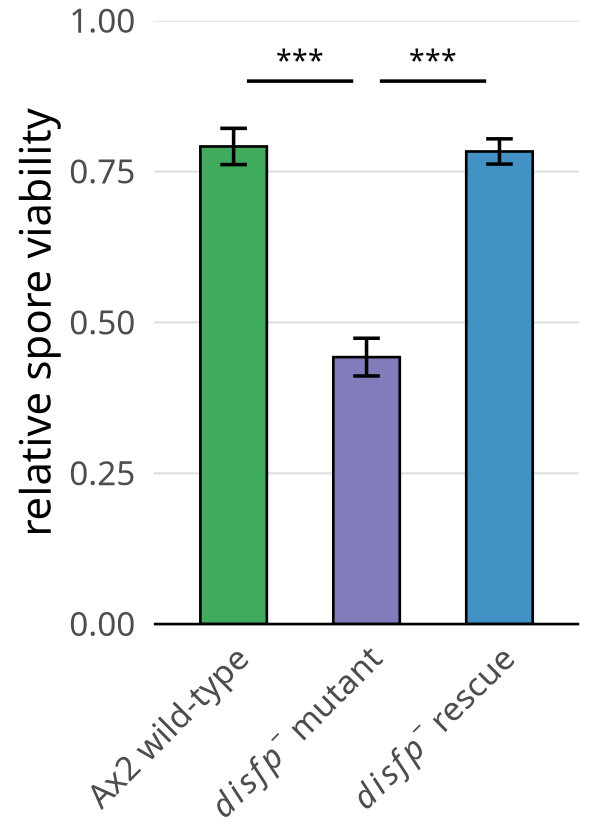

In [42]:
options(repr.plot.width = 5, repr.plot.height = 7)

p_sporeV <- ggplot(data_sporeV_sum, aes(x = strain, y = spore_viability.mean, fill = strain)) + 
  geom_col(position = position_dodge(), width = 0.5, color = "black", size = 0.75) +
  geom_errorbar(
    aes(ymin = spore_viability.mean - spore_viability.se,
        ymax = spore_viability.mean + spore_viability.se),
    width = 0.2,
    position = position_dodge(0.5),
    size = 1
  ) +
  geom_segment(
    data = annotations_V,
    aes(x = x_min, xend = x_max, y = y, yend = y),
    inherit.aes = FALSE,
    color = "black",
    size = 1
  ) +
  geom_text(
    data = annotations_V,
    aes(x = (x_min + x_max) / 2, y = y, label = label),
    inherit.aes = FALSE,
    vjust = -0.5,
    size = 6
  ) +
  scale_fill_manual(values = strain_colors) +
  theme_light(base_size = 25) +
  theme(
    panel.border       = element_blank(),
    panel.spacing      = unit(3, "lines"),
    axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.line.x        = element_line(color = "black", size = 0.75),
    axis.ticks.x       = element_blank(),
    axis.ticks.y       = element_blank(),
    strip.text.x       = element_text(color = "black", face = "bold"),
    strip.background   = element_rect(colour = "white", fill = "white", size = NA, linetype = "solid")
  ) + 
  guides(fill = FALSE) + 
  labs(x = NULL, y = "relative spore viability") +
  scale_x_discrete(labels = strain_rename) +
  scale_y_continuous(expand = expansion(mult = c(0, 0)), limits = c(0, 1))

p_sporeV


## Export spore production/viability plots for main figures

In [46]:
# Plot: spore production per sorus
p_sporeP <- data_spores %>%
  ggplot(aes(x = strain, y = (spore_count/10), fill = strain)) +
  geom_boxplot(alpha = 1, outlier.shape = NA, linewidth = 0.15) +
  geom_segment(data = annotations, aes(x = x_min, xend = x_max, y = y, yend = y), 
               inherit.aes = FALSE, color = "black", size = .2) +
  geom_text(data = annotations, aes(x = (x_min + x_max) / 2, y = y, label = label), 
            inherit.aes = FALSE, nudge_y  = 0.075, hjust = .5, size = 3) +
  scale_fill_manual(values = strain_colors) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "spores per sorus") +
  theme_minimal(base_size = 8) +
  scale_y_log10(
    breaks = trans_breaks("log10", function(x) 10^x),
    labels = trans_format("log10", math_format(10^.x)),
    limits = c(NA, 0.2*10^7)
  ) +
  guides(fill = FALSE) +
  annotation_logticks(
    sides = "l",
    short = unit(0.05, "cm"),
    mid = unit(0.1, "cm"),
    long = unit(0.15, "cm"),
    colour = "black",
    linewidth = 0.2
  ) +
  theme(
    axis.title = element_text(color = "black"),
    axis.text = element_text(color = "black"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    panel.grid.major.y = element_line(color = "grey75", size = .15),
    strip.text.x = element_text(color = "black", face = "bold"),
    strip.background = element_rect(colour = "white", fill = "white",
                                    size = NA, linetype = "solid")
  )

# Plot: relative spore viability
p_sporeV <- ggplot(data_sporeV_sum, aes(x=strain, y=spore_viability.mean, fill=strain)) + 
  geom_col(position=position_dodge(), width=0.5, color="black", size=0.125) +
  geom_errorbar(
    aes(ymin=spore_viability.mean - spore_viability.se, ymax=spore_viability.mean + spore_viability.se),
    width=.2, position=position_dodge(0.5), size = .2
  ) +
  geom_segment(data = annotations_V, aes(x = x_min, xend = x_max, y = y, yend = y), 
               inherit.aes = FALSE, color = "black", size = .2) +
  geom_text(data = annotations_V, aes(x = (x_min + x_max) / 2, y = y, label = label), 
            inherit.aes = FALSE, nudge_y  = 0.0075, hjust = .5, size = 3) +
  scale_fill_manual(values=strain_colors) +
  theme_light(base_size = 8) +
  theme(
    axis.title = element_text(color = "black"),
    axis.text = element_text(color = "black"),
    panel.border = element_blank(),
    panel.spacing = unit(3, "lines"),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    panel.grid.major.y = element_line(color = "grey75", size = .15),
    axis.line.x = element_line(color = "black", size = .15),
    axis.text.x = element_text(angle = 45, hjust = 1),
    axis.ticks.x = element_blank(),
    axis.ticks.y = element_blank(),
    strip.text.x = element_text(color="black", face="bold"), 
    strip.background = element_rect(colour="white", fill="white", size=NA, linetype="solid")
  ) + 
  guides(fill = FALSE) + 
  labs(x=NULL, y="relative spore viability") +
  scale_x_discrete(labels = strain_rename) +
  scale_y_continuous(expand = expansion(mult = c(0, 0)), limits = c(0, 1))

# Combine and export
fb_assays_plot <- p_sporeP + p_sporeV

save_path <- file.path(wd, "03_results", "img", "fb_assays_plot.svg")

ggsave(save_path, plot = fb_assays_plot, width = 87 / 25.4, height = 50.5 / 25.4, 
       units = "in", bg = "transparent", device = svglite, create.dir = TRUE)


## Plaque size

### Prepare data

In [48]:
# Load and reshape plaque size data
data_plaque_raw <- read_excel(excel_data_path, sheet = "Plaque_size")

data_plaque <- data_plaque_raw %>% 
  pivot_longer(cols = everything(), names_to = "strain", values_to = "plaque_size") %>% 
  mutate(strain = case_when(
    strain == 'AX2' ~ 'wt',
    strain == 'Disfp_ko' ~ 'ko',
    strain == 'Disfp_R' ~ 're'
  )) %>%
  mutate(strain = factor(strain, levels = strain_levels))

### ANOVA

In [50]:
# Fit ANOVA model
anova_model <- aov(plaque_size ~ strain, data = data_plaque)

# Tukey HSD post-hoc test
tukey_test <- TukeyHSD(anova_model)

# Format Tukey results
tukey_results <- tukey_test$`strain`
tukey_results <- data.frame(Comparison = rownames(tukey_results), tukey_results) %>%
  mutate(significance = case_when(
    p.adj < 0.001 ~ "***",
    p.adj < 0.01  ~ "**",
    p.adj < 0.05  ~ "*",
    TRUE          ~ ""
  ))

# Define annotations for significance bars
y_sigline <- 22
annotations <- data.frame(
  x_min = c(1.1, 1.1, 2.1),
  x_max = c(1.9, 2.9, 2.9),
  y = c(y_sigline, y_sigline + 5, y_sigline),
  label = tukey_results$significance,
  p.adj = tukey_results$p.adj
) %>% filter(p.adj <= 0.05)

### Plot

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encoding latin1”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“font metrics unknown for character 0x0a in encodin

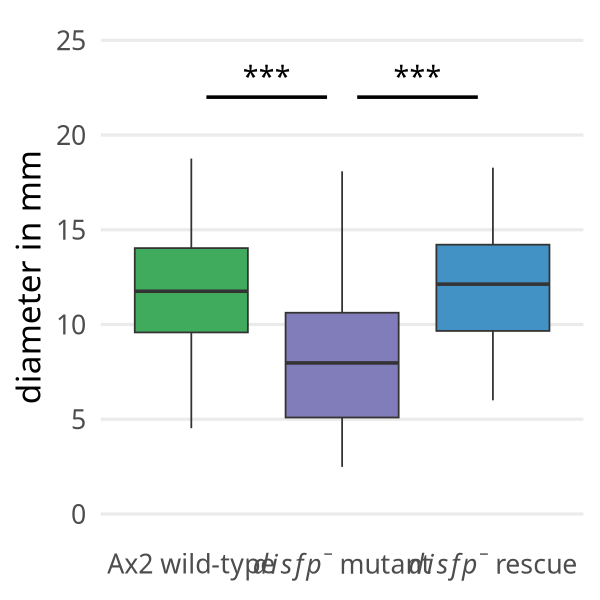

In [53]:
options(repr.plot.width = 5, repr.plot.height = 5)

p_sporeQ <- data_plaque %>%
  ggplot(aes(x = strain, y = plaque_size, fill = strain)) +
  geom_boxplot(alpha = 1) +
  geom_segment(data = annotations, aes(x = x_min, xend = x_max, y = y, yend = y),
               inherit.aes = FALSE, color = "black", size = 1) +
  geom_text(data = annotations, aes(x = (x_min + x_max) / 2, y = y, label = label),
            inherit.aes = FALSE, vjust = -0.5, size = 6) +
  scale_fill_manual(values = strain_colors) +
  scale_x_discrete(labels = strain_rename) +
  labs(x = NULL, y = "diameter in mm") +
  theme_minimal(base_size = 20) +
  guides(fill = FALSE) +
  ylim(c(0, 25)) +
  theme(
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.minor.y = element_blank(),
    strip.text.x = element_text(color = "black", face = "bold"),
    strip.background = element_rect(colour = "white", fill = "white", size = NA, linetype = "solid")
  )

p_sporeQ
